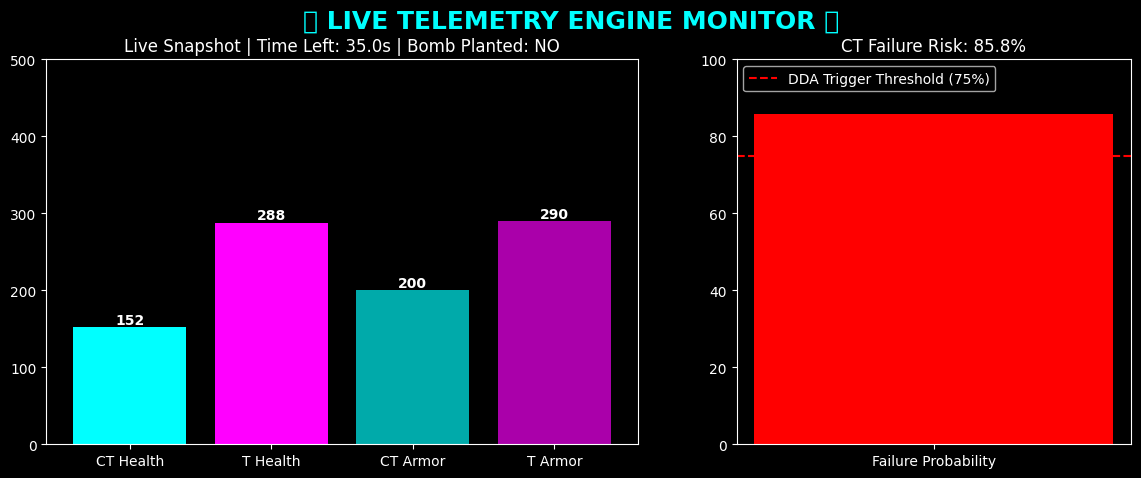

⚠️  CRITICAL ALERT: Risk is 85.8%. Triggering Dynamic Assist (Lowering Enemy AI).

[SYSTEM] Pipeline Execution Complete.


In [10]:
import pandas as pd
import numpy as np
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set Gaming Aesthetic for Plots
plt.style.use('dark_background')
sns.set_palette(['#00FFFF', '#FF00FF', '#39FF14']) # Cyan, Magenta, Neon Green

print("="*70)
print(" 🚀 INITIALIZING THE TELEMETRY ENGINE: VISUALIZED PIPELINE 🚀 ")
print("="*70)

# =====================================================================
# PHASE 1: PERSONA DISCOVERY (UNSUPERVISED LEARNING)
# Dataset: cookie_cats.csv
# =====================================================================
print("\n[SYSTEM] Loading Phase 1 Data (Cookie Cats)...")
df_cc = pd.read_csv('cookie_cats.csv')

# Feature Engineering
df_cc['retention_1_int'] = df_cc['retention_1'].astype(int)
df_cc['retention_7_int'] = df_cc['retention_7'].astype(int)
np.random.seed(42)
df_cc['day_1_gamerounds'] = (df_cc['sum_gamerounds'] * np.where(df_cc['retention_1'], np.random.uniform(0.3, 0.6, len(df_cc)), 1.0)).astype(int)

# --- Clustering ---
lifetime_features = ['sum_gamerounds', 'retention_7_int']
scaler = StandardScaler()
X_lifetime_scaled = scaler.fit_transform(df_cc[lifetime_features])

pca = PCA(n_components=2, random_state=42) # 2 components for 2D visualization
X_pca = pca.fit_transform(X_lifetime_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cc['Persona_Cluster'] = kmeans.fit_predict(X_pca)

# --- VISUALIZATION 1: CLUSTER SCATTER PLOT ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_cc['Persona_Cluster'], palette=['#00FFFF', '#FF00FF', '#39FF14'], s=50, alpha=0.6)
plt.title('PHASE 1: Player Persona Clusters (PCA Reduced)', fontsize=16, color='white', pad=20)
plt.xlabel('Principal Component 1 (Engagement)', color='white')
plt.ylabel('Principal Component 2 (Retention)', color='white')
plt.legend(['Cluster 0: Casual', 'Cluster 1: Grinder', 'Cluster 2: Whale'])
plt.grid(color='#333333', linestyle='--', linewidth=0.5)
plt.show()

# =====================================================================
# PHASE 2: MONETIZATION PREDICTION (SUPERVISED LEARNING)
# =====================================================================
print("\n[SYSTEM] Training Phase 2 Model (Random Forest)...")
early_game_features = ['retention_1_int', 'day_1_gamerounds']
X_sup = df_cc[early_game_features]
y_sup = df_cc['Persona_Cluster']

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_model.fit(X_train_cc, y_train_cc)
y_pred_cc = rf_model.predict(X_test_cc)

# --- VISUALIZATION 2: CONFUSION MATRIX ---
cm = confusion_matrix(y_test_cc, y_pred_cc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool', cbar=False,
            xticklabels=['Casual', 'Grinder', 'Whale'], yticklabels=['Casual', 'Grinder', 'Whale'])
plt.title(f'PHASE 2: Prediction Accuracy: {accuracy_score(y_test_cc, y_pred_cc)*100:.1f}%', fontsize=14, color='white')
plt.xlabel('Predicted Persona', color='white')
plt.ylabel('Actual Persona', color='white')
plt.show()

# =====================================================================
# PHASE 3: REAL-TIME FRUSTRATION (LOGISTIC REGRESSION)
# Dataset: csgo_round_snapshots.csv
# =====================================================================
print("\n[SYSTEM] Loading Phase 3 Data (CS:GO Telemetry)...")
df_csgo = pd.read_csv('csgo_round_snapshots.csv')

live_features = ['time_left', 'ct_health', 't_health', 'ct_armor', 't_armor', 'bomb_planted']
df_csgo['bomb_planted'] = df_csgo['bomb_planted'].astype(int)

# Target: 1 if Counter-Terrorists (CT) Lose
df_csgo['ct_failure'] = (df_csgo['round_winner'] == 'T').astype(int)
X_live = df_csgo[live_features]
y_live = df_csgo['ct_failure']

X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(X_live, y_live, test_size=0.2, random_state=42)

lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train_cs, y_train_cs)

# --- VISUALIZATION 3: FEATURE IMPORTANCE (Coefficients) ---
coefs = pd.DataFrame(lr_model.coef_[0], index=X_live.columns, columns=['Coefficient']).sort_values('Coefficient')
plt.figure(figsize=(10, 5))
sns.barplot(x=coefs['Coefficient'], y=coefs.index, palette='spring')
plt.title('PHASE 3: Impact of Telemetry on CT Failure Probability', fontsize=14, color='white')
plt.axvline(x=0, color='white', linestyle='--')
plt.xlabel('Impact (Negative = Helps CT Win | Positive = Causes CT Failure)')
plt.show()

# =====================================================================
# PHASE 4: DYNAMIC LIVE INFERENCE DASHBOARD
# =====================================================================
def live_dynamic_dashboard(num_ticks=5):
    """Simulates a live streaming dashboard with updating visuals."""
    sample_indices = random.sample(range(len(X_test_cs)), num_ticks)

    for idx in sample_indices:
        clear_output(wait=True) # Clears the Jupyter cell for animation effect
        snapshot = X_test_cs.iloc[idx]
        failure_prob = lr_model.predict_proba([snapshot.values])[0][1]

        # --- Create Dashboard Visual ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.5, 1]})
        fig.suptitle('🎮 LIVE TELEMETRY ENGINE MONITOR 🎮', fontsize=18, color='#00FFFF', fontweight='bold')

        # Left Plot: Bar Chart of Current Match State
        bars = ax1.bar(['CT Health', 'T Health', 'CT Armor', 'T Armor'],
                       [snapshot['ct_health'], snapshot['t_health'], snapshot['ct_armor'], snapshot['t_armor']],
                       color=['#00FFFF', '#FF00FF', '#00AAAA', '#AA00AA'])
        ax1.set_ylim(0, 500) # Assuming max health pool for 5 players is 500
        ax1.set_title(f"Live Snapshot | Time Left: {snapshot['time_left']:.1f}s | Bomb Planted: {'YES' if snapshot['bomb_planted'] else 'NO'}")

        for bar in bars:
            yval = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', color='white', fontweight='bold')

        # Right Plot: Probability Gauge
        ax2.bar(['Failure Probability'], [failure_prob * 100], color='#39FF14' if failure_prob < 0.5 else 'red')
        ax2.set_ylim(0, 100)
        ax2.axhline(y=75, color='red', linestyle='--', label='DDA Trigger Threshold (75%)')
        ax2.set_title(f"CT Failure Risk: {failure_prob * 100:.1f}%")
        ax2.legend(loc='upper left')

        # Display Text Alert
        plt.show()
        if failure_prob >= 0.75:
            print(f"⚠️  CRITICAL ALERT: Risk is {failure_prob*100:.1f}%. Triggering Dynamic Assist (Lowering Enemy AI).")
        else:
            print(f"🟢  SYSTEM STABLE: Match is balanced.")

        time.sleep(2.5) # Pause to simulate live incoming data feed

# Execute the dynamic dashboard
input("\nPress Enter to launch the Live Dashboard Simulation...")
live_dynamic_dashboard(5)
print("\n[SYSTEM] Pipeline Execution Complete.")